In [ ]:
#Na początku analizy zaimportowano podstawowe biblioteki, które są potrzebne do wykonania projektu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Nastęnie wczytano dane (wcześniej wgrano plik)
df = pd.read_csv("titanic.csv")

#Sprawdzono jak prezentują się dane w tabeli
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#W kolejnym kroku sprawdzono informacje o strukturze danych
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Zbiór ma 891 wierszy i 12 kolumn. Większość danych jest kompletna, jednak:
- kolumna Age ma sporo wartości null (177),
- kolumna Embarked ma 2 braki,
- kolumna Cabin ma prawie same puste wartości (687), możemy uznać, że jest praktycznie bezużyteczna.

Natomiast typy danych są poprawne. Zmienna docelowa Survived jest kompletna, więc nadaje się do analizy. Największym wyzwaniem w przygotowaniu danych będzie uzupełnienie wieku, usunięcie lub pominięcie Cabin oraz uzupełnienie Embarked. Wszystko inne wygląda czysto i gotowe do dalszej analizy.

In [ ]:
#Sprawdzono podstawowe statystyki dla zmiennych numerycznych
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Średni wiek pasażerów to około 30 lat. Najmłodszy z podróżnych ma mniej niż rok, a najstarszy 80. Większość osób nie ma rodzeństwa/małżonka/rodziców/dzieci na pokładzie, więc większość podróżowała sama. Cena biletu ma ogromny rozstrzał, ponieważ większość płaciła niewiele (mediana ~14), ale są też zdecydownie droższe bilety (ponad 500), co wskazuje na silne różnice między klasami. Klasa podróży jest również zróżnicowana. Najwięcej osób było w 3 klasie. Odsetek przeżycia jest niski (średnia ~0.38), co potwierdza, że większość pasażerów nie przeżyła katastrofy. W danych widać też sporo wartości odstających, szczególnie w cenach biletów i liczbie krewnych (np. rodziny z 8 osobami). Wszystko to sugeruje, że rozkłady są nierówne, a zmienne takie jak wiek, klasa i cena biletu mogą mieć duży wpływ na przeżycie.

In [ ]:
#Następnie sprawdzono podstawowe statystyki dla zmiennych kategorycznych
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Kolumna Name ma 891 unikalnych wartości, czyli każdy z podróżujących ma unikalne imię i nazwisko. W kolumnie Sex pojawiają się dwie wartości male i female. Najczęściej występuje male (577 razy), więc mężczyźni stanowią większość pasażerów. Kolumna Ticket posiada 681 różnych numerów biletów, ale niektóre powtarzają się (najczęstszy występuje 7 razy). Prawdopodobnie część osób podróżowała razem. W kolejnej kolumnie Cabin jest tylko 204 wartości, które nie są null. Embarked zawiera trzy możliwe porty (S, C, Q). Najwięcej osób wsiadło w porcie S (644 razy).

In [ ]:
#W kolejnym kroku sprawdzam liczbę wartości null h w każdej kolumnie
df.isna().sum().sort_values(ascending=False)


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Największym problemem jakości danych są braki w Cabin i Age, tak jak zostało stwierdzone to wcześniej. Reszta zbioru jest gotowa do dalszej analizy.

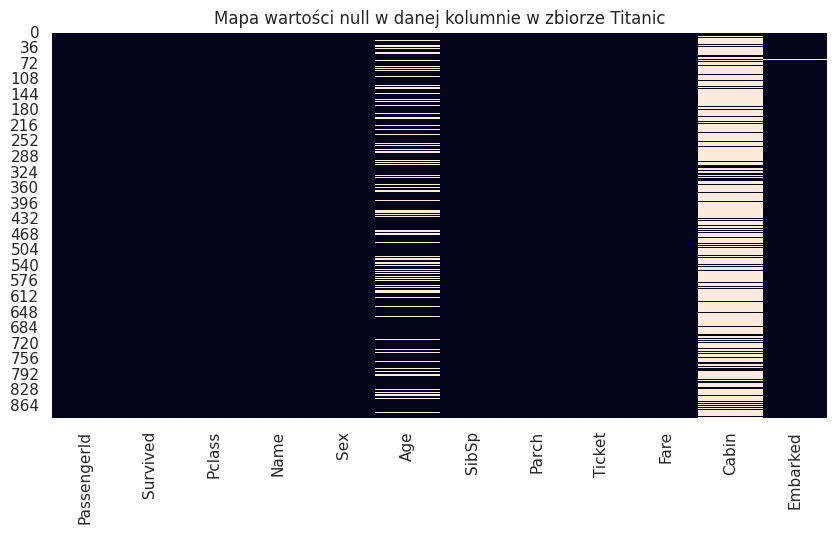

In [ ]:
#W celu lepszego zobrazowania braków danych w kolumnach stworzono poniższą wizualizację
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa wartości null w danej kolumnie w zbiorze Titanic")
plt.show()

Heatmapa potwierdza to, co pokazały wcześniejsze statystyki. Największy problem to kolumna Cabin, potem Age.

In [ ]:
#W kolejnym kroku usunięto kolumnę Cabin, ze względu na zbyt dużo braków
df = df.drop(columns=["Cabin"])

In [ ]:
#Następnie uzupełniono puste wartości w kolumnie Embarked najczęściej występującymi wartością
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

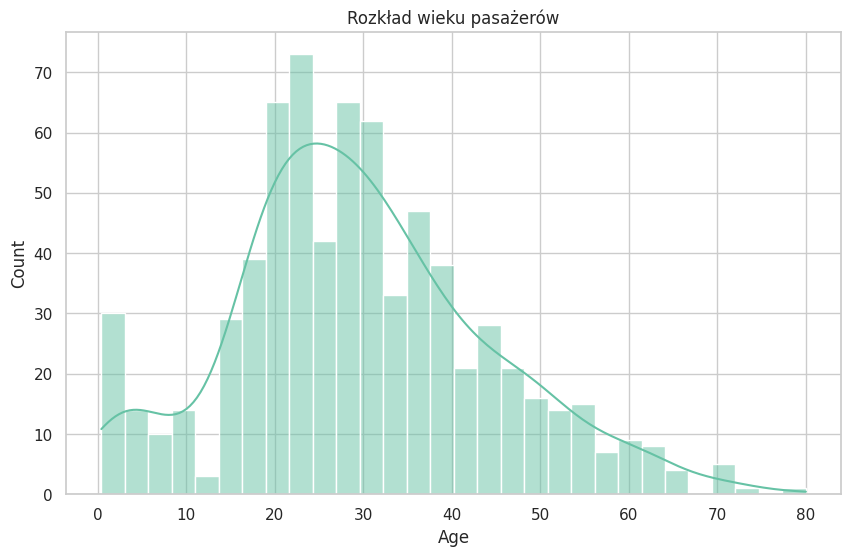

In [ ]:
#W następnej wizualizacji przedstawiono histogram wieku pasażerów
sns.histplot(data=df, x="Age", kde=True, bins=30)
plt.title("Rozkład wieku pasażerów")
plt.show()

Najwięcej pasażerów miało 20-30 lat, ale również można zauważyć sporo osób w wieku około 30–40 lat. Dzieci jest wyraźnie mniej niż dorosłych, ale są obecne w danych. Można stwierdzić, że rozkład jest asymetryczny: dużo młodych, mało starszych. Należy również uwzględnić braki danych w wieku (histogram nie obejmuje pełnych 891 osób).

In [ ]:
#Następnie uzupełeniono wartości null w Age medianą
df["Age"] = df["Age"].fillna(df["Age"].median())

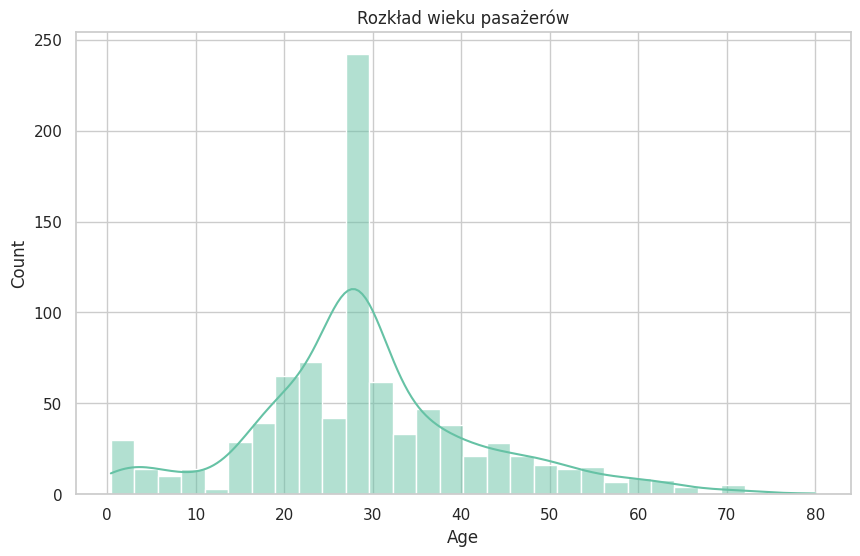

In [ ]:
#W następnej wizualizacji przedstawiono kolejny raz histogram wieku pasażerów,
#w celu sprawdzenia jak prezentują się dane po uzupełnieniu braków
sns.histplot(data=df, x="Age", kde=True, bins=30)
plt.title("Rozkład wieku pasażerów")
plt.show()

W rozkładzie wieku dalej widać, że najwięcej pasażerów ma około 30 lat. Uzupełnienie braków medianą sprawiło, że nie ma już dziur w danych, a wykres jest pełny. Nadal widać, że młodych dorosłych jest najwięcej, a im starsza grupa, tym mniej pasażerów.

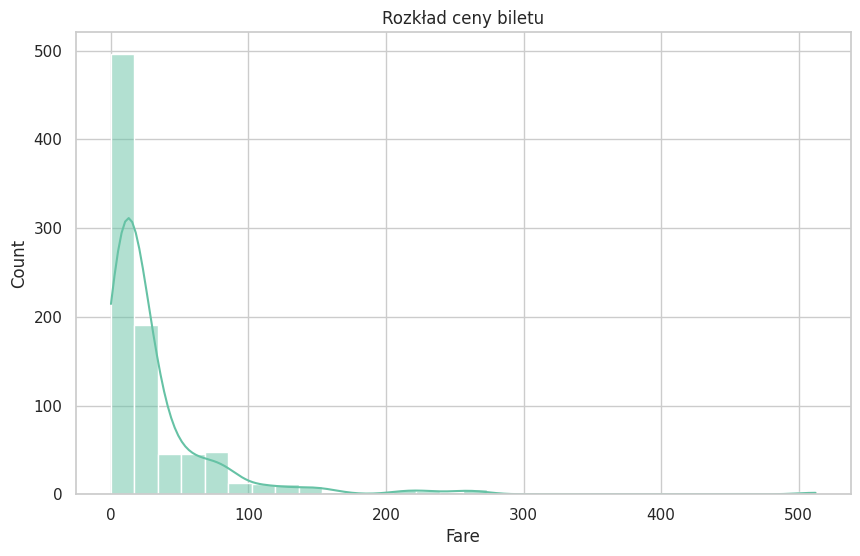

In [ ]:
#W kolejnym kroku przedstawiono histogram ceny biletu
sns.histplot(data=df, x="Fare", kde=True, bins=30)
plt.title("Rozkład ceny biletu")
plt.show()

Większość pasażerów zapłaciła bardzo mało za bilet, dlatego widać duże skupienie wartości przy niskich cenach. Warto zauważyć, że rozkład jest mocno skośny. Posiada długi „ogon” w prawo, co oznacza, że niewielka grupa osób zapłaciła bardzo wysokie kwoty. Wysokie ceny to bilety pasażerów z 1 klasy, co potwierdza duże różnice społeczne na statku. Różnice w cenach są ogromne, co sugeruje, że kolumna Fare może być ważnym czynnikiem w analizie przeżycia.

In [ ]:
#W następnym kroku sprawdzono, czy po poprzednich modyfikacjach pozostały jakieś wartości null
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


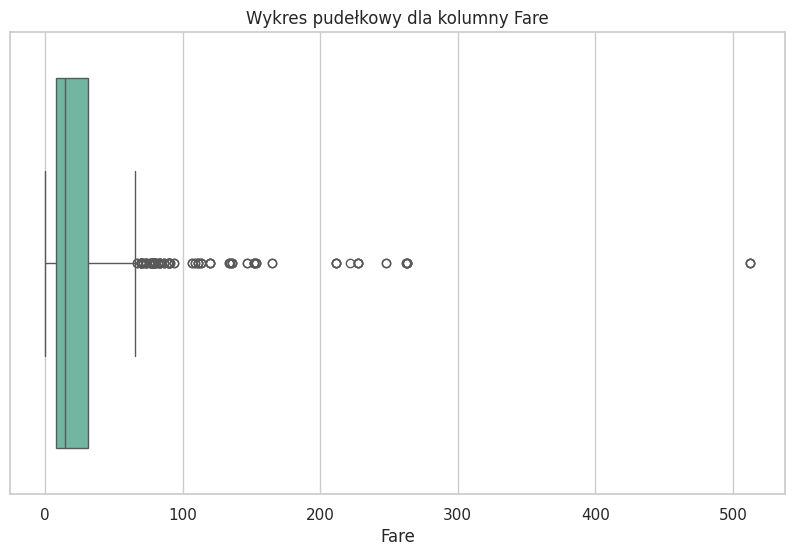

In [ ]:
#W kolejnym kroku zaprezentowano wykres pudełkowy dla kolumny Fare
sns.boxplot(x=df["Fare"])
plt.title("Wykres pudełkowy dla kolumny Fare")
plt.show()


Większość cen biletów jest niska i skupiona blisko dolnej części wykresu. Mediana ceny biletu jest niska, co potwierdza, że większość pasażerów podróżowała głównie w 3 klasie. Na wykresie znajduje się bardzo dużo wartości odstających. Pojedyńcze bilety były drogie. Prawdopodobnie ceny tych biletów pochodziły od pasażerów z 1 klasy. Pokazuje to duże różnice majątkowe na statku.

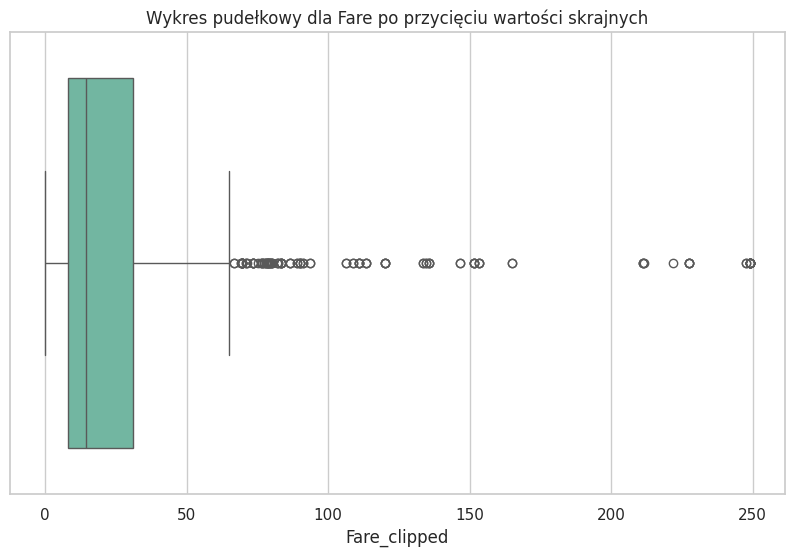

In [ ]:
#Ze względu na mocno nierówny rozkład zdecydowano przyciąć skrajne wartości.

fare_q99 = df["Fare"].quantile(0.99)
df["Fare_clipped"] = np.where(df["Fare"] > fare_q99, fare_q99, df["Fare"])

sns.boxplot(x=df["Fare_clipped"])
plt.title("Wykres pudełkowy dla Fare po przycięciu wartości skrajnych")
plt.show()

::Po przycięciu wartości skrajnych rozkład ceny biletu wygląda dużo bardziej równomiernie. Największe ekstremalne dane zostały ograniczone, więc wykres lepiej pokazuje typowe ceny, a nie pojedyńcze bardzo drogie bilety. Nadal jednak widać kilka odstających punktów, ale jest ich znacznie mniej niż wcześniej. Mediana i główna część rozkładu pozostały takie same.

In [ ]:
#W dalszej analizie zmieniono zmienną Sex na wartości binarne
#W poniższym kodzie użyto "Sex_male", ponieważ w przypadku dwóch kategorii (male i female) jedna kolumna w zupełności wystarczy
df["Sex_male"] = (df["Sex"] == "male").astype(int)

#Następnie stworzono prostą kategoryzację wieku (child/adult/senior)
def age_group(age):
    if age < 18:
        return "child"
    elif age < 60:
        return "adult"
    else:
        return "senior"

df["AgeGroup"] = df["Age"].apply(age_group)

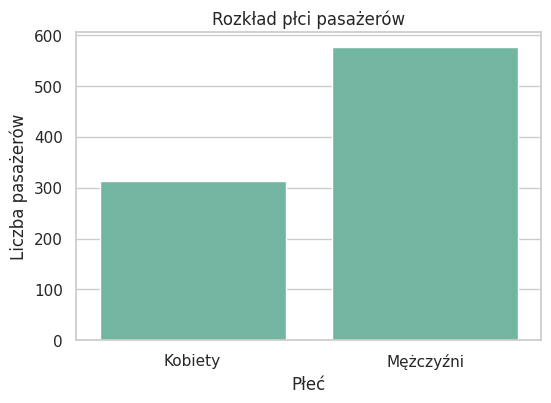

In [ ]:
#W kolejnym kroku przedstawiono wykres przedstawiający rozkład płci pasażerów
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex_male")
plt.title("Rozkład płci pasażerów")
plt.xlabel("Płeć")
plt.ylabel("Liczba pasażerów")
plt.xticks([0, 1], ["Kobiety", "Mężczyźni"])
plt.show()


Na statku było dużo więcej mężczyzn niż kobiet. Struktura płci była mocno niezrównoważona. Ma to znaczenie przy analizie przeżycia, ponieważ kobiet było mniej, więc ich przeżywalność była wyższa. Dodatkowo norma etyczna „kobiety i dzieci przodem” również miała znaczenie w przeżywalności kobiet.


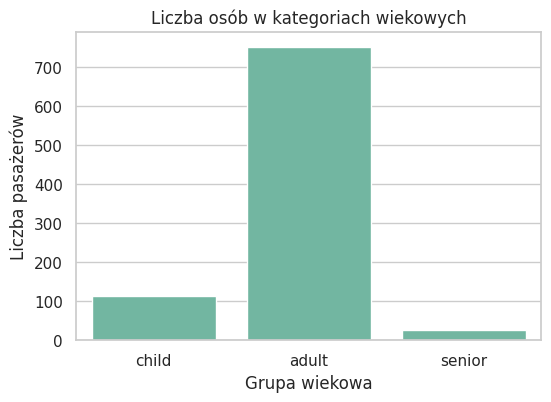

In [ ]:
#Następnie przedstawiono wykres słupkowy dla grup wiekowych, które zostały wcześniej stworzone.
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="AgeGroup", order=["child", "adult", "senior"])
plt.title("Liczba osób w kategoriach wiekowych")
plt.xlabel("Grupa wiekowa")
plt.ylabel("Liczba pasażerów")
plt.show()


Zdecydowana większość pasażerów to dorośli (ponad 700 osób). Dzieci stanowią niewielką część pasażerów, ale jest ich zauważalnie więcej niż seniorów. Seniorzy stanowią najmniejszą grupę wiekową na statku.

In [ ]:
#W kolejnym kroku zmieniono zmienne kategoryczne na zmienne liczbowe
df = pd.get_dummies(df, columns=["Embarked", "Pclass", "AgeGroup"], drop_first=True)

df.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Fare_clipped,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,AgeGroup_child,AgeGroup_senior
0,1,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,7.2500,1,False,True,False,True,False,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,71.2833,0,False,False,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,7.9250,0,False,True,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,53.1000,0,False,True,False,False,False,False
4,5,0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,8.0500,1,False,True,False,True,False,False


In [ ]:
#W analizie uwzględniono średni odsetek przeżycia według płci
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


Kobiety miały bardzo wysoką przeżywalność (około 74% z nich przeżyło).

Mężczyźni mieli bardzo niską przeżywalność (tylko około 19% przeżyło).


In [ ]:
#W kolejnym kroku policzono średnią przeżywalności pasażerów według klasy
print("Klasa 1:", df[(df["Pclass_2"] == 0) & (df["Pclass_3"] == 0)]["Survived"].mean())
print("Klasa 2:", df[df["Pclass_2"] == 1]["Survived"].mean())
print("Klasa 3:", df[df["Pclass_3"] == 1]["Survived"].mean())


Klasa 1: 0.6296296296296297
Klasa 2: 0.47282608695652173
Klasa 3: 0.24236252545824846


Klasa 1 miała najwyższą przeżywalność (około 63% pasażerów przeżyło).

Klasa 2 miała średnią przeżywalność (około 47%).

Klasa 3 miała najniższą przeżywalność (tylko 24% pasażerów przeżyło).

Im wyższa klasa, tym większe szanse na dostęp do łodzi ratunkowych i tym większa przeżywalność. Status społeczno-ekonomiczny był jednym z kluczowych czynników wpływających na szanse przeżycia na Titanicu.

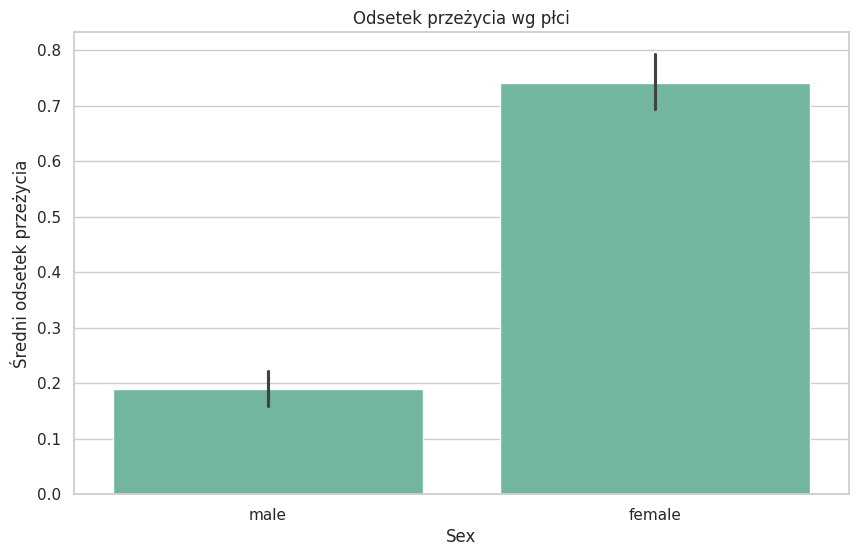

In [ ]:
#W nastęnym kroku przedstawiono histogram dotyczący wpływu płci na przeżycie
sns.barplot(data=df, x="Sex", y="Survived", estimator=np.mean)
plt.title("Odsetek przeżycia wg płci")
plt.ylabel("Średni odsetek przeżycia")
plt.show()

Kobiety miały zdecydowanie wyższy odsetek przeżycia niż mężczyźni. Płeć była jednym z najsilniejszych czynników wpływających na szanse przeżycia na Titanicu.

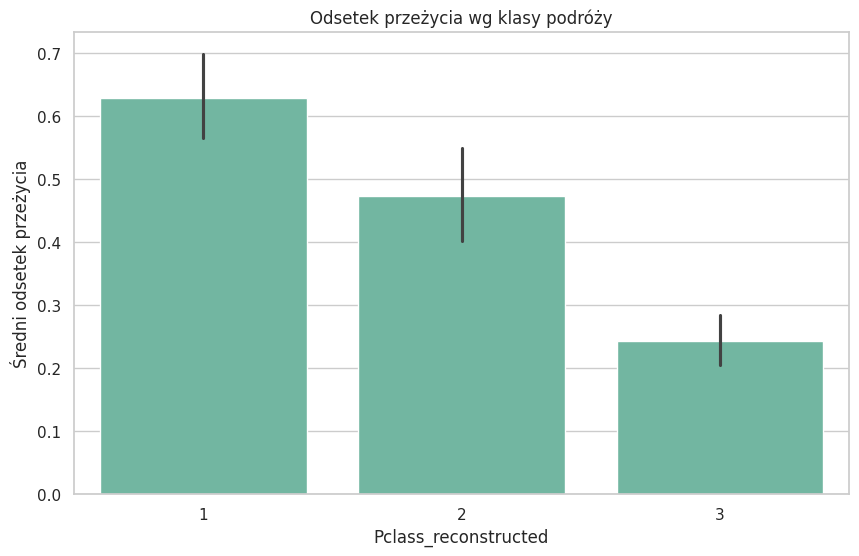

In [ ]:
#W analizie przedsawiono histogram dotyczący wpływu klasy na przeżycie
#Jednak na początku stworzono kolumne "Pclass_reconstructed", która zawiera wszystkie klasy.

df["Pclass_reconstructed"] = (
    df["Pclass_2"] * 2 +
    df["Pclass_3"] * 3
)
df.loc[(df["Pclass_2"] == 0) & (df["Pclass_3"] == 0), "Pclass_reconstructed"] = 1

sns.barplot(data=df, x="Pclass_reconstructed", y="Survived", estimator=np.mean)
plt.title("Odsetek przeżycia wg klasy podróży")
plt.ylabel("Średni odsetek przeżycia")
plt.show()

Klasa 1 miała najwyższy odsetek przeżycia. Pasażerowie tej klasy mieli najlepszy dostęp do łodzi ratunkowych i byli ewakuowani w pierwszej kolejności. Klasa 2 miała średni poziom przeżycia, lepszy niż klasa 3, ale wyraźnie gorszy niż klasa 1. Klasa 3 miała najniższy odsetek przeżycia, ponieważ pasażerowie tej klasy mieli najgorsze warunki i najmniejsze szanse na dotarcie do łodzi ratunkowej.

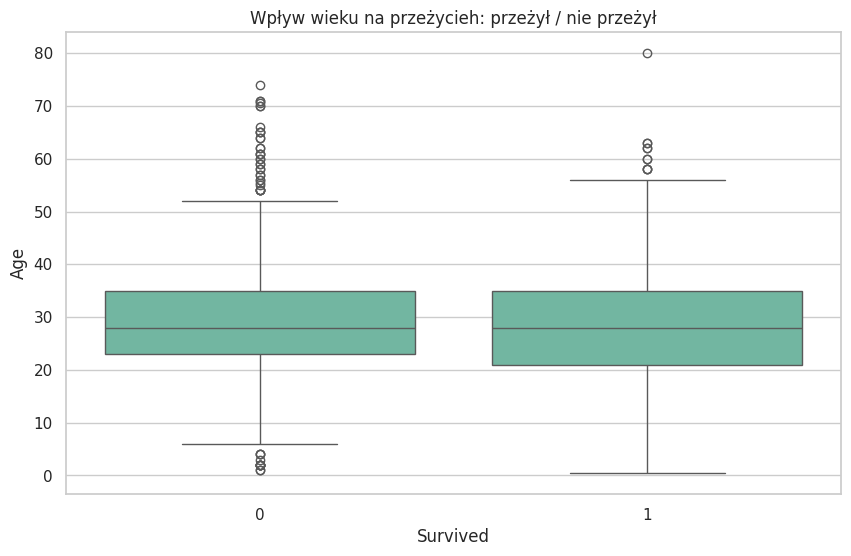

In [ ]:
#W kolejnym kroku przedstawiono wykres dotyczący wpływu wieku na przeżycie
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Wpływ wieku na przeżycieh: przeżył / nie przeżył")
plt.show()

Mediany wieku dla obu grup (przeżył / nie przeżył) są bardzo podobne, więc wiek nie był głównym czynnikiem decydującym o przeżyciu. W obu grupach występują zarówno osoby młode, jak i starsze. Widać jednak, że w grupie osób, które nie przeżyły, jest więcej pasażerów w wieku dorosłym (szczególnie 20–40 lat). W grupie osób, które przeżyły, pojawia się nieco więcej dzieci. Prawdopodobnie wynika to z zasady „kobiety i dzieci przodem”.

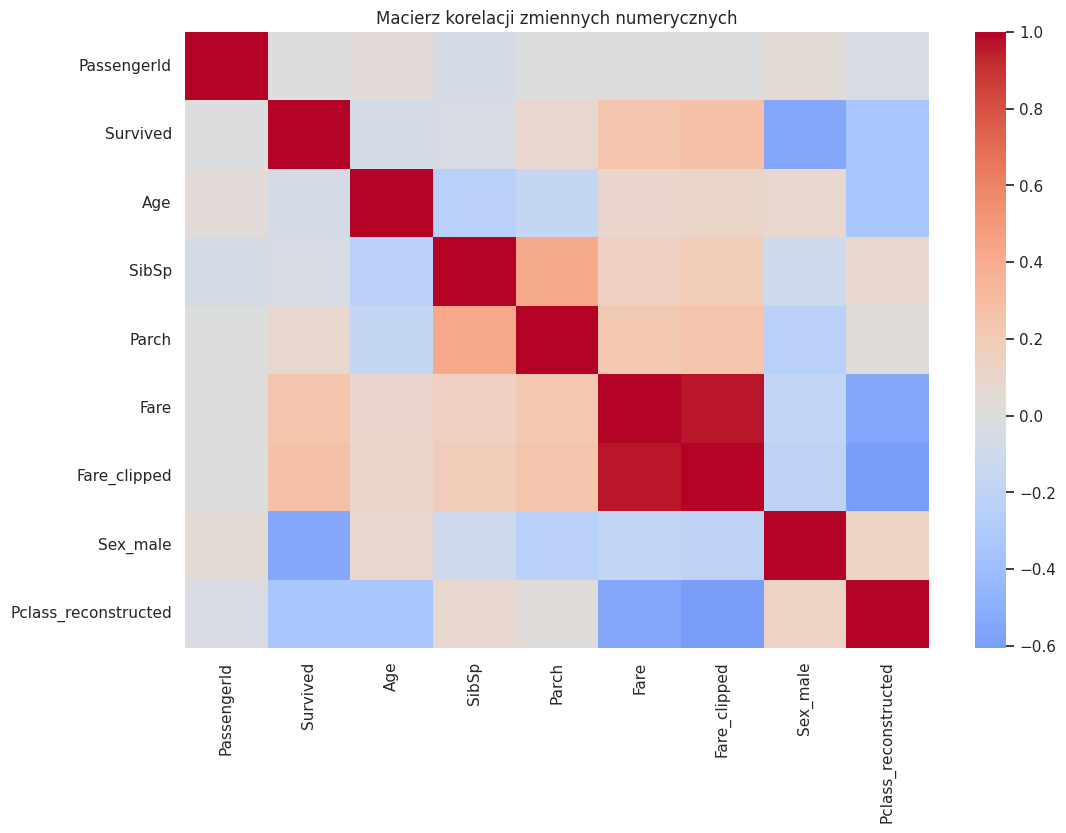

,Survived
Survived,1.000000
Fare_clipped,0.273008
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.064910
Pclass_reconstructed,-0.338481
Sex_male,-0.543351


In [ ]:
#Następnie przedstawiono analizę macierzy korelacji
numeric_cols = df.select_dtypes(include=[np.number])

corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

corr["Survived"].sort_values(ascending=False)


Najsilniejszą zależność z przeżyciem ma płeć, ponieważ zmienna Sex_male ma korelację -0.54, co oznacza, że bycie mężczyzną mocno obniżało szanse przeżycia. Drugim najsilniejszym czynnikiem jest klasa podróży, ze względu na to, że zmienna Pclass_reconstructed ma korelację -0.33, czyli im niższa klasa, tym mniejsze szanse przeżycia. Cena biletu (Fare i Fare_clipped) ma pozytywną korelację z przeżyciem (ok. 0.26–0.27), co oznacza, że osoby płacące więcej (czyli zwykle z wyższej klasy) częściej przeżywały. Wiek (Age) ma bardzo słabą korelację z przeżyciem.


PODUSMOWANIE:

Przeprowadzona analiza danych z katastrofy Titanica pozwoliła na identyfikację kluczowych czynników wpływających na prawdopodobieństwo przeżycia pasażerów. W pierwszym etapie oceniono jakość danych, wskazując na znaczące braki w kolumnie Cabin oraz umiarkowane braki w zmiennej Age. Po uzupełnieniu braków wieku medianą oraz przycięciu skrajnych wartości ceny biletu uzyskano odpowiedni zbiór danych do dalszych analiz.

Analiza rozkładów wykazała, że większość pasażerów stanowili młodzi dorośli, a struktura płci była wyraźnie niezrównoważona. Mężczyzn było około dwukrotnie więcej niż kobiet. Podział na grupy wiekowe potwierdził dominację osób dorosłych, przy niewielkim udziale dzieci i seniorów.

Najważniejsze wnioski dotyczące przeżywalności wynikają z analizy zależności między zmiennymi a zmienną Survived. Najsilniejszym czynnikiem okazała się płeć. Kobiety przeżywały znacznie częściej niż mężczyźni. Drugim kluczowym czynnikiem była klasa podróży. Pasażerowie 1 klasy mieli najwyższe szanse przeżycia, podczas gdy pasażerowie 3 klasy najniższe. Cena biletu, będąca pośrednim wskaźnikiem statusu społeczno-ekonomicznego, również wykazywała dodatnią korelację z przeżyciem. Wiek natomiast miał jedynie marginalny wpływ na wynik, co potwierdziła zarówno analiza rozkładów, jak i korelacji.

Macierz korelacji jednoznacznie wskazała, że zmienne związane z płcią i klasą podróży są najistotniejsze w kontekście przeżycia. Pozostałe zmienne, takie jak liczba członków rodziny na pokładzie czy wiek, miały niewielkie znaczenie statystyczne.

Analiza potwierdziła, że o przeżyciu na Titanicu decydowały przede wszystkim czynniki społeczne: płeć oraz klasa podróży. Wyniki te są spójne z historycznymi relacjami dotyczącymi przebiegu ewakuacji i zasadą „kobiety i dzieci pierwsze”.